# Mirror Randomised Benchmarking (MRB): Hardware Experiments

This notebook was used to run experiments on real ibm_fez.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
import matplotlib.pyplot as plt
from qiskit_device_benchmarking.bench_code.mrb import  MirrorRB
from qiskit import transpile
from qiskit.circuit.library import iqp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.transpiler.passes import Optimize1qGates
import os, random

# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)


QiskitRuntimeService.save_account(
    token="", # Your token is confidential.
    instance="", # Optionally specify the instance to use.
    name="", # Optionally name this set of account credentials.
    set_as_default=True, # Optionally set these as your default credentials.
    overwrite=True   
)

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")

In [2]:
# Define parameters for the simulated backend
num_qubits = 20
shots = 10000
lengths = [2]+[4,10,20,50,100]
num_samples = 20

# Set up the experiment object
exp = MirrorRB(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples, 
    seed=SEED
)

# Set run options
exp.set_run_options(shots=shots)
exp.set_transpile_options(
    basis_gates=None,      # Allows auto-translation to ECR (native for FEZ)  # Includes translation + basic routing
    seed_transpiler=SEED,    # Reproducible
)

# Run the experiment with timing
rb_data = exp.run()
print("Job IDs:", rb_data.job_ids)

Job IDs: ['d4et2bh2bisc73a1sim0']


DEBUG Ei: 0.0504+/-0.0010


DEBUG Ei: 0.0504+/-0.0010


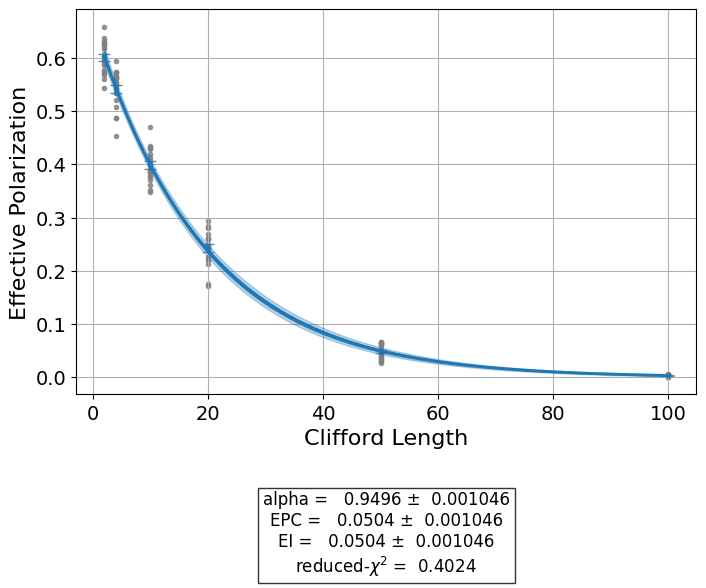

In [3]:
from qiskit_device_benchmarking.bench_code.mrb.mirror_rb_analysis import MirrorRBAnalysis

analysis_obj = MirrorRBAnalysis()
analysis_obj.set_options(analyzed_quantity='Effective Polarization')
analysis = analysis_obj.run(rb_data)
analysis.block_for_results()
analysis.figure(0)

### Save the Benchmark Configuration and Circuits

This section saves the experiment data for future use. A folder named with the experiment's **job ID** is created, and the number of qubits, the random seed, and all generated MRB circuits are stored inside it. Saving this information makes the experiment **reproducible**, allowing the same circuits and configuration to be reloaded or shared without rerunning the circuit generation process.


In [4]:
import os
import json
import qiskit
import qiskit.qasm2

# Get the job id
job_id = rb_data.job_ids[0]

# Create a folder with the job id as name
os.makedirs(job_id, exist_ok=True)

# Save qubit number
with open(f'{job_id}/{job_id}_qubits.json', 'w') as f:
    json.dump({"num_qubits": num_qubits}, f)

# Save circuits
for i, circ in enumerate(exp.circuits()):
    with open(os.path.join(job_id, f'circuit_{i}.json'), 'w') as f:
        qiskit.qasm2.dump(circ, f)

# Save the seed
with open(f'{job_id}/{job_id}_seed.json', 'w') as f:
    json.dump({"seed": SEED}, f)

In [5]:
# Save the MRB plot (extract matplotlib figure from FigureData)
fig = analysis.figure(0).figure
fig.savefig(f'{job_id}/{job_id}_mrb_plot.png', dpi=300, bbox_inches='tight')

 ### Compare Gate Counts Before and After Transpilation

This section compares the number of **single-qubit (1Q)** and **two-qubit (2Q)** gates before and after transpilation. The helper function counts the gates across all MRB circuits and prints a summary showing the additional gates introduced during transpilation. This provides a simple measure of the transpilation overhead, which can affect both circuit depth and benchmark performance. The list of two-qubit gates (`cz`, `cx`, `ecr`, `iswap`) can be modified if a different gate set is used by the backend.


In [6]:
# Get original (untranspiled) and transpiled circuits
original_circuits   = exp.circuits()              # before transpilation
transpiled_circuits = exp._transpiled_circuits()  # after transpilation

def count_1q_2q(circuits):
    total_1q = 0
    total_2q = 0
    for circ in circuits:
        for gate, count in circ.count_ops().items():
            # Adjust this list if your backend uses cx, ecz, iswap, etc. instead of cz
            if gate in {'cz', 'cx', 'ecr', 'iswap'}:  
                total_2q += count
            else:
                total_1q += count   # everything else is treated as 1-qubit gate
    return total_1q, total_2q

# Before transpilation
pre_1q, pre_2q = count_1q_2q(original_circuits)

# After transpilation
post_1q, post_2q = count_1q_2q(transpiled_circuits)

# Pretty print the summary
print("\n=== Gate Count Summary (all RB circuits) ===")
print(f"Before transpilation :  1Q gates = {pre_1q:6d}   |   2Q gates = {pre_2q:5d}")
print(f"After  transpilation :  1Q gates = {post_1q:6d}   |   2Q gates = {post_2q:5d}")
print(f"Overhead             :  1Q +{post_1q - pre_1q:+6d}   |   2Q +{post_2q - pre_2q:+5d}")
print("==========================================\n")



=== Gate Count Summary (all RB circuits) ===
Before transpilation :  1Q gates = 128668   |   2Q gates = 18826
After  transpilation :  1Q gates = 287156   |   2Q gates = 18826
Overhead             :  1Q ++158488   |   2Q +   +0



In [7]:
# Count operations after transpilation
print("\nOperations after transpilation for circuit 0:")
transpiled_circuits= exp._transpiled_circuits()
print(transpiled_circuits[0].count_ops())
print("\n1Q and 2Q gates after transpilation for all circuits:")
for i, circ in enumerate(transpiled_circuits):
    total_1q_gates_trans = 0
    total_2q_gates_trans = 0
    for gate, count in circ.count_ops().items():
        if gate in ['cz']:
            total_2q_gates_trans += count
        else:
            total_1q_gates_trans += count
    print(f"Circuit {i} transpiled: Total 1Q gates: {total_1q_gates_trans}, Total 2Q gates: {total_2q_gates_trans}")



Operations after transpilation for circuit 0:
OrderedDict({'rz': 150, 'sx': 60, 'x': 33, 'measure': 20, 'barrier': 8, 'cz': 8})

1Q and 2Q gates after transpilation for all circuits:
Circuit 0 transpiled: Total 1Q gates: 271, Total 2Q gates: 8
Circuit 1 transpiled: Total 1Q gates: 405, Total 2Q gates: 12
Circuit 2 transpiled: Total 1Q gates: 843, Total 2Q gates: 46
Circuit 3 transpiled: Total 1Q gates: 1567, Total 2Q gates: 100
Circuit 4 transpiled: Total 1Q gates: 3729, Total 2Q gates: 232
Circuit 5 transpiled: Total 1Q gates: 7383, Total 2Q gates: 476
Circuit 6 transpiled: Total 1Q gates: 281, Total 2Q gates: 10
Circuit 7 transpiled: Total 1Q gates: 445, Total 2Q gates: 24
Circuit 8 transpiled: Total 1Q gates: 898, Total 2Q gates: 56
Circuit 9 transpiled: Total 1Q gates: 1665, Total 2Q gates: 120
Circuit 10 transpiled: Total 1Q gates: 3877, Total 2Q gates: 286
Circuit 11 transpiled: Total 1Q gates: 7483, Total 2Q gates: 536
Circuit 12 transpiled: Total 1Q gates: 273, Total 2Q gates:

In [8]:
# Count operations before transpilation for circuit 0
print("Operations before transpilation:")
original_circuits = exp.circuits()
print(original_circuits[0].count_ops())
# Count 1Q and 2Q for each circuit before transpilation
print("1Q and 2Q gates before transpilation for all circuits:")
for i, circ in enumerate(original_circuits):
    total_1Q_gates = 0
    total_2Q_gates = 0
    for gate, count in circ.count_ops().items():
        if gate in ['cz']:
            total_2Q_gates += count
        else:
            total_1Q_gates += count
    print(f"Circuit {i}: Total 1Q gates: {total_1Q_gates}, Total 2Q gates: {total_2Q_gates}")

Operations before transpilation:
OrderedDict({'measure': 20, 'Clifford-1Q(0)': 19, 'Clifford-1Q(18)': 18, 'Clifford-1Q(6)': 17, 'Clifford-1Q(12)': 14, 'Clifford-1Q(5)': 8, 'barrier': 8, 'cx': 8, 'Clifford-1Q(3)': 8, 'Clifford-1Q(19)': 6, 'Clifford-1Q(7)': 6, 'Clifford-1Q(4)': 5, 'Clifford-1Q(22)': 5, 'Clifford-1Q(21)': 3, 'Clifford-1Q(17)': 3, 'Clifford-1Q(15)': 3, 'Clifford-1Q(11)': 3, 'Clifford-1Q(16)': 2, 'Clifford-1Q(1)': 2, 'Clifford-1Q(13)': 2})
1Q and 2Q gates before transpilation for all circuits:
Circuit 0: Total 1Q gates: 160, Total 2Q gates: 0
Circuit 1: Total 1Q gates: 240, Total 2Q gates: 0
Circuit 2: Total 1Q gates: 458, Total 2Q gates: 0
Circuit 3: Total 1Q gates: 824, Total 2Q gates: 0
Circuit 4: Total 1Q gates: 1952, Total 2Q gates: 0
Circuit 5: Total 1Q gates: 3808, Total 2Q gates: 0
Circuit 6: Total 1Q gates: 158, Total 2Q gates: 0
Circuit 7: Total 1Q gates: 228, Total 2Q gates: 0
Circuit 8: Total 1Q gates: 448, Total 2Q gates: 0
Circuit 9: Total 1Q gates: 804, Total